### 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [45]:
import os
from typing import Annotated, Sequence, TypedDict

# Core & Message Types
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.tools import Tool

# Community Tools & Utilities
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# LangGraph Constructs
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain.agents import create_agent

In [3]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [4]:
retriever.invoke("what are autonomous agents")

[Document(id='d8d6aa9a-24d4-4c1e-9218-0f93117f4905', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [5]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [6]:
retriever_tool_func("What are autonomous agents")

📚 Using RAGRetriever tool


'Boiko et al. (2023) also looked into LLM-empowered agents for scientific discovery, to handle autonomous design, planning, and performance of complex scientific experiments. This agent can use tools to browse the Internet, read documentation, execute code, call robotics experimentation APIs and leverage other LLMs.\nFor example, when requested to "develop a novel anticancer drug", the model came up with the following reasoning steps:\nCitation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\nOr\n@article{weng2023agent,\n  title   = "LLM-powered Autonomous Agents",\n  author  = "Weng, Lilian",\n  journal = "lilianweng.github.io",\n  year    = "2023",\n  month   = "Jun",\n  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"\n}\nReferences#\n[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022\n[2] Yao et al. “Tree of Thoughts: Dliberate P

In [7]:
retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [14]:
# Wikipedia tool
# Set a custom user-agent globally for the underlying wikipedia library
import wikipedia
wikipedia.set_lang("en")
wikipedia.set_user_agent("MyLangGraphApp/1.0 (contact: myemail@example.com)")
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'e:\\RAG\\RAG Project KN\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [15]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("gpt-4.1-mini-2025-04-14")

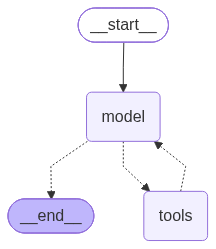

In [16]:
# ----------------------------
# 2. Define the Agent Node
# ----------------------------



tools = [retriever_tool, wiki_tool]

## create the native Langgraph react agent
react_node=create_agent(llm,tools)
react_node

In [17]:
# --------------------------
# 3. LangGraph Agent State
# --------------------------

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

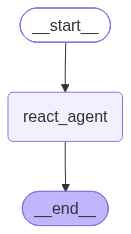

In [18]:
# --------------------------
# 4. Build LangGraph Graph
# --------------------------

builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [19]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)


✅ Final Answer:
 An "agent loop" is not explicitly defined in the Wikipedia search results I found, but it generally refers to the continuous cycle in which an intelligent agent perceives its environment, decides on an action based on its objectives, and executes that action, often repeatedly to achieve its goals.

Regarding "autonomous agents," Wikipedia describes an autonomous agent as an artificial intelligence (AI) system capable of performing complex tasks independently. These agents perceive their environment, take actions autonomously to achieve goals, and may improve their performance through learning or acquiring knowledge. Autonomous agents are a subset of intelligent agents, which are entities that operate based on an objective function and create plans to maximize the expected value of this function.

In essence, autonomous agents are intelligent systems that pursue goals and take actions with varying degrees of autonomy within defined objectives and constraints.


### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [1]:
import os
from typing import Annotated, Sequence, TypedDict
from langchain_core.tools import Tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.agents import create_agent
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_community.document_loaders import TextLoader

C:\Users\itsme\AppData\Local\Temp\ipykernel_9456\4246178966.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
llm

NameError: name 'llm' is not defined

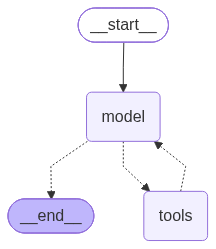

In [3]:
import uuid
from langchain_community.document_loaders import TextLoader, ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import tool
from langchain_core.tools import create_retriever_tool
from langchain.agents import create_agent
# 1. Use built-in create_retriever_tool to avoid closure scope issues
def make_retriever_tool_from_text(file: str, name: str, desc: str):
    docs = TextLoader(file, encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()
    
    # create_retriever_tool creates a fully-typed StructuredTool out-of-the-box
    return create_retriever_tool(retriever, name, desc)

# 2. Wikipedia Tool (using @tool for clean signature inspection)
wiki_api = WikipediaAPIWrapper()

@tool("Wikipedia")
def wiki_tool(query: str) -> str:
    """Use this tool to fetch general world knowledge from Wikipedia."""
    return wiki_api.run(query)

# 3. ArXiv Tool
@tool("ArxivSearch")
def arxiv_tool(query: str) -> str:
    """Use this tool to fetch recent academic papers on technical topics."""
    print("🧪 Searching ArXiv...")
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."

# 4. Instantiate Internal Tools
internal_tool_1 = make_retriever_tool_from_text(
    "internal_docs.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)

internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)

# 5. Build Tools List and Create Agent
tools = [wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Use modern LangGraph prebuilt executor
react_node = create_agent(llm, tools)
react_node

In [4]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

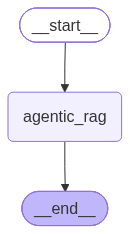

In [5]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph

In [6]:
query = "What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

🧪 Searching ArXiv...


AttributeError: 'Search' object has no attribute 'results'

In [7]:
query = "What is the purpose Automated image classification pipeline & python version used"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

🧪 Searching ArXiv...


AttributeError: 'Search' object has no attribute 'results'